# Team 8:-
- Ronak Pipaliya
- Sajan Shergill
- Darpan Gorasiya

Analyze the `diabetes.csv` dataset by training and evaluating both Perceptron and Multilayer Perceptron models.

In [ ]:
y_reg = df['BMI']
X_reg = df.drop(['Outcome', 'BMI'], axis=1)

scaler_reg = StandardScaler()
X_reg_scaled = scaler_reg.fit_transform(X_reg)

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg_scaled, y_reg, test_size=0.2, random_state=42)

print("Data prepared for MLP Regressor:")
print(f"y_reg shape: {y_reg.shape}")
print(f"X_reg shape: {X_reg.shape}")
print(f"X_reg_scaled shape: {X_reg_scaled.shape}")
print(f"X_reg_train shape: {X_reg_train.shape}")
print(f"X_reg_test shape: {X_reg_test.shape}")
print(f"y_reg_train shape: {y_reg_train.shape}")
print(f"y_reg_test shape: {y_reg_test.shape}")

Data prepared for MLP Regressor:
y_reg shape: (768,)
X_reg shape: (768, 7)
X_reg_scaled shape: (768, 7)
X_reg_train shape: (614, 7)
X_reg_test shape: (154, 7)
y_reg_train shape: (614,)
y_reg_test shape: (154,)


## Train Multilayer Perceptron Regressor

### Subtask:
Initialize and train a `MLPRegressor` model using the prepared training data. Given that training can take a long time, the model will be configured with a reasonable `max_iter` and a `random_state` for reproducibility.


In [ ]:
from sklearn.neural_network import MLPRegressor

# Initialize an MLPRegressor model
mlp_regressor = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42, early_stopping=True)

# Train the MLP Regressor model
mlp_regressor.fit(X_reg_train, y_reg_train)

print("MLP Regressor model trained successfully.")

MLP Regressor model trained successfully.


## Make Predictions with MLP Regressor

### Subtask:
Use the trained `MLPRegressor` model to make predictions on the test set and display a sample of these predictions.


In [ ]:
y_reg_pred = mlp_regressor.predict(X_reg_test)

print("Sample of MLP Regressor Predictions:")
print(y_reg_pred[:10])

Sample of MLP Regressor Predictions:
[32.37522378 32.37493607 28.1428321  31.8939905  30.22522916 31.78618673
 25.77181297 27.49637718 29.54025698 25.9290402 ]


## Plot Loss Curves

### Subtask:
Plot the loss curve generated during the training of the `MLPRegressor` to visualize the model's learning process over iterations.


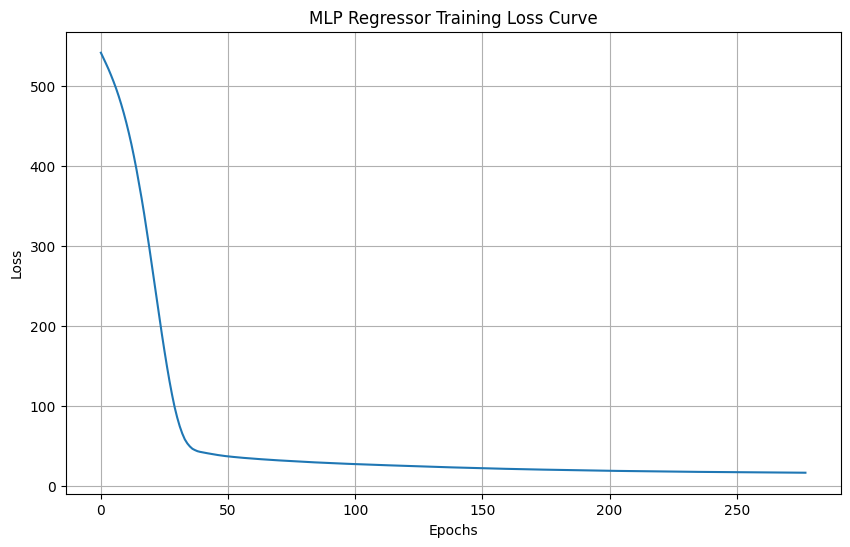

In [ ]:
import matplotlib.pyplot as plt

# Access the loss curve
loss_curve = mlp_regressor.loss_curve_

# Plot the loss curve
plt.figure(figsize=(10, 6))
plt.plot(loss_curve)
plt.title('MLP Regressor Training Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.show()


## Compare Final Training and Test Loss

### Subtask:
Calculate and compare the final loss (e.g., Mean Squared Error) of the MLPRegressor on both the training and test sets to assess for overfitting or underfitting.


In [ ]:
from sklearn.metrics import mean_squared_error

# Make predictions on the training set
y_reg_train_pred = mlp_regressor.predict(X_reg_train)

# Calculate Mean Squared Error for the training set
mse_train = mean_squared_error(y_reg_train, y_reg_train_pred)

# Calculate Mean Squared Error for the test set (y_reg_pred was already calculated)
mse_test = mean_squared_error(y_reg_test, y_reg_pred)

print(f"Training Mean Squared Error: {mse_train:.4f}")
print(f"Test Mean Squared Error: {mse_test:.4f}")

Training Mean Squared Error: 33.1664
Test Mean Squared Error: 63.3555


## Compare Final Training and Test Loss

### Subtask:
Calculate and compare the final loss (e.g., Mean Squared Error) of the MLPRegressor on both the training and test sets to assess for overfitting or underfitting.

In [ ]:
print("MLP Regressor Weights and Biases:")

# Access weights (coefficients) and biases (intercepts)
weights = mlp_regressor.coefs_
biases = mlp_regressor.intercepts_

# Display weights for each layer
for i, layer_weights in enumerate(weights):
    print(f"\nWeights for Layer {i+1} (Input Size: {layer_weights.shape[0]}, Output Size: {layer_weights.shape[1]}):")
    print(layer_weights)

# Display biases for each layer
for i, layer_biases in enumerate(biases):
    print(f"\nBiases for Layer {i+1} (Size: {layer_biases.shape[0]}):")
    print(layer_biases)

MLP Regressor Weights and Biases:

Weights for Layer 1 (Input Size: 7, Output Size: 100):
[[ 5.09547618e-03  3.13106443e-01  1.63061928e-01  7.67793111e-02
  -2.27244337e-01 -1.81473411e-01 -2.49377115e-01  2.51502688e-01
   3.65008842e-02  1.44310430e-02 -2.65294961e-01  2.74970865e-01
   2.25173129e-01 -1.84968941e-01 -1.83984173e-01 -2.75787887e-01
  -1.44383308e-01  9.41895533e-02  8.61315868e-03 -1.40961488e-01
   5.69970359e-02 -2.10729218e-01 -5.21150473e-02  1.23762579e-02
  -2.65738936e-02  2.16930494e-01 -1.63137656e-01 -2.11336605e-02
  -3.57353453e-02 -2.66737391e-01  1.32180774e-01 -1.28327099e-01
  -2.19422656e-01  3.12390009e-01  3.27233683e-01  2.50326005e-01
  -9.00405836e-02 -1.30718356e-01  8.38607640e-02 -7.33866039e-02
  -1.59933404e-01  3.85552482e-03 -2.55526733e-01  3.56685188e-01
  -1.27826192e-01  1.34360044e-01 -1.21491732e-01  1.34874316e-01
   1.38155054e-01 -2.10602779e-01  3.31963018e-01  2.05356345e-01
   2.57975108e-01  2.53543115e-01  3.66700352e-02  3

## Summary:

### Data Analysis Key Findings

*   **Performance Assessment:**
    *   The **Training Mean Squared Error (MSE)** was `33.1664`.
    *   The **Test Mean Squared Error (MSE)** was `63.3555`.
    *   The significant difference between the training and test MSE indicates that the model is **overfitting** the training data, performing much better on seen data than on unseen data.
*   **Model Parameters:** The weights and biases of the trained MLP Regressor were successfully extracted:
    *   **Weights:** Shapes of `(7, 100)` for Layer 1, `(100, 50)` for Layer 2, and `(50, 1)` for Layer 3.
    *   **Biases:** Shapes of `(100,)` for Layer 1, `(50,)` for Layer 2, and `(1,)` for Layer 3.
